In [1]:
import numpy as np
list_marks = [45,32,56,75,89,54,32,89,90,87,67,54,98,99,67,74]
minimum, Q1, median, Q3, maximum = np.quantile(list_marks, [0, 0.25, 0.5, 0.75, 1])
print("Minimum:", minimum)
print("Q1:", Q1)
print("Median:", median)
print("Q3:", Q3)        
print("Maximum:", maximum)

Minimum: 32.0
Q1: 54.0
Median: 70.5
Q3: 89.0
Maximum: 99.0


In [2]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)  
print(IQR)

Lower Bound: 1.5
Upper Bound: 141.5
35.0


<Axes: >

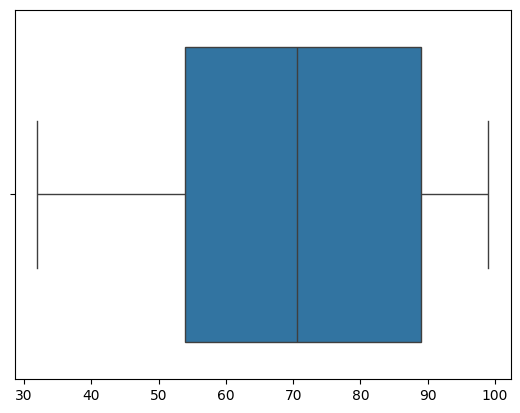

In [4]:
import seaborn as sns
sns.boxplot(x=list_marks)

<Axes: >

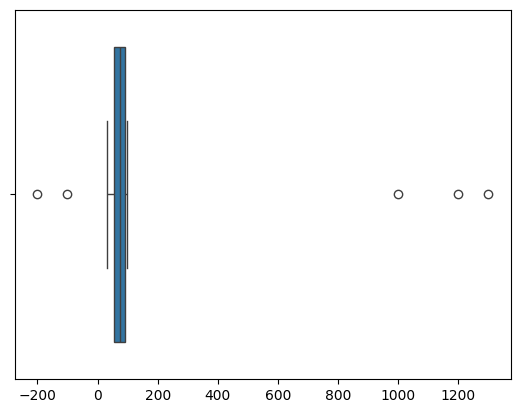

In [5]:
list_marks = [-100,-200,45,32,56,75,89,54,32,89,90,87,67,54,98,99,67,74,1000,1200,1300]
import seaborn as sns
sns.boxplot(x=list_marks)

In [6]:
import pandas as pd
df = pd.DataFrame({
    'color': ['red','blue','green','green','red','blue']
})
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [15]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [20]:
encoded_data = encoder.fit_transform(df[['color']]).toarray()

In [23]:
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())
encoded_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


Label Encoding 
instead of OHE, label encoding provides a unique value for each and every categorical datapoint


In [24]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [28]:
label_encoder.fit_transform(df['color'])

array([2, 0, 1, 1, 2, 0])

In [30]:
#Ordinal Encoding for relative ranking in categorical data
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()


In [32]:
df = pd.DataFrame({
    'size': ['small','medium','large','medium','small','large']
})


In [36]:
encoder = OrdinalEncoder(categories=[['small','medium','large']])
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [37]:
#Target guided Ordinal Encoding technique

import pandas as pd 
df = pd.DataFrame({
    'city': ['NewYork', 'London', 'Paris', 'Tokyo', 'NewYork','Paris'],
    'price': [200,150,300,250,180,320]
})
df

,city,price
0,NewYork,200
1,London,150
2,Paris,300
3,Tokyo,250
4,NewYork,180
5,Paris,320


In [38]:
mean_price = df.groupby('city')['price'].mean().to_dict()

In [39]:
mean_price

{'London': 150.0, 'NewYork': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [40]:
df['city_encoded'] = df['city'].map(mean_price)
df

,city,price,city_encoded
0,NewYork,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,NewYork,180,190.0
5,Paris,320,310.0
